### Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
from scipy.stats import linregress
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

base_dir = os.getcwd()
parent_dir = os.path.dirname(base_dir)
os.chdir(parent_dir)

np.random.seed(101)

print(f"Current Directory: {os.getcwd()}")

Current Directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study


### Load in expert rating

In [2]:
# read in the doubling time data
dt = pd.read_csv("data/procdata/1_doublingRate/model_doubling_times.csv", usecols=["modelID", "global_doubling_time"], index_col="modelID")

# read in the RNA-seq data
df = pd.read_csv("data/rawdata/uhn_breast/omics/rna_tpm_hugo.tsv", sep="\t", index_col=0)

# filter to only protein-coding genes
gene_info = pd.read_csv("data/rawdata/uhn_breast/omics/geneInfo.tab", sep="\t", header=None, names=["ensembl_id", "symbol", "biotype"])
gene_info = gene_info[gene_info["biotype"] == "protein_coding"]
protein_coding_genes = set(gene_info["symbol"])

df = df.transpose()
df = df.loc[:, df.columns.isin(protein_coding_genes)]
print(f"Models in RNA-seq: {len(df)}") # if you kept a copy
df = np.log2(df + 1)
df = df.loc[:, df.var() > 0]

df = df.merge(dt, left_index=True, right_index=True, how="inner")

print(f"Models in DT list: {len(dt)}")
print(f"Models in Final DF: {df.shape[0]}")


print(df.shape)


Models in RNA-seq: 95
Models in DT list: 95
Models in Final DF: 75
(75, 19693)


In [7]:
# read in the doubling time data
dt = pd.read_csv("data/procdata/1_doublingRate/model_doubling_times.csv", usecols=["modelID", "global_doubling_time"], index_col="modelID")

# read in the RNA-seq data
df = pd.read_csv("data/rawdata/uhn_breast/omics/rna_tpm_hugo.tsv", sep="\t", index_col=0)

# Assuming 'df' is your log-transformed RNA-seq data BEFORE the merge
rna_models = df.T.index
dt_models = dt.index

print(dt_models)

# Models present in RNA-seq but missing from Doubling Time data
missing_in_dt = rna_models.difference(dt_models)

print(f"Number of models in RNA but not in DT: {len(missing_in_dt)}")
print("Missing Models:", list(missing_in_dt))

Index(['S01-1104', 'S100534', 'S100672', 'S100804', 'S104987', 'S108045',
       'S108099', 'S16720', 'S17518', 'S178200', 'S18674', 'S20710', 'S23223',
       'S241417', 'S28077', 'S28992', 'S38807', 'S44205', 'S44441', 'S44721',
       'S47904', 'S48041', 'S48342', 'S48602', 'S53522', 'S53782', 'S65465',
       'S66280', 'S66292', 'S66684', 'S66817', 'S67725', 'S67870', 'S67990',
       'S69196', 'S69693', 'S70620', 'S71208', 'S71335', 'S71732', 'S72642',
       'S72877', 'S72955', 'S73009', 'S73062', 'S73230', 'S73263', 'S73471',
       'S85277', 'S91142', 'BPTO51', 'BPTO95', 'BXTO64', 'INSB014', 'INSB019',
       'NOTCH01', 'NOTCH06', 'NOTCH10', 'NOTCH18', 'NOTCHB01', 'NOTCHB03',
       'REF001', 'REF002', 'REF004', 'REF005', 'REF006', 'REF007', 'REF009',
       'REF010', 'REF013', 'REF014', 'REF016', 'REF019', 'REF020', 'REF022',
       'REF023', 'REF025', 'REF030', 'REF032', 'REF032B', 'REF034', 'REF035',
       'REF036', 'REF037', 'REF043', 'REF044', 'REF045', 'REF047', 'REF048'

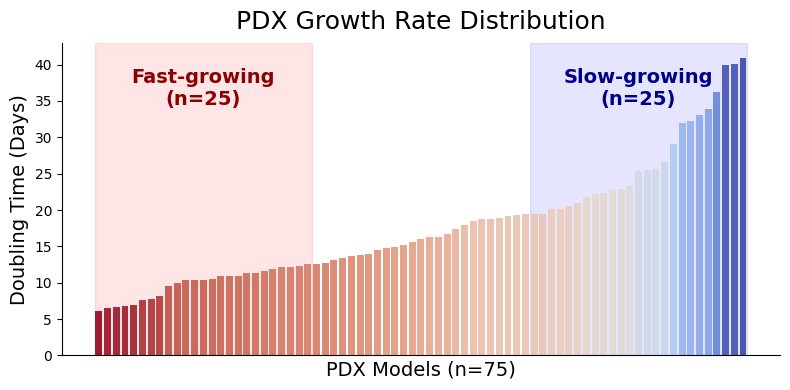

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

per_model_df = df.copy()

per_model_df = per_model_df.sort_values("global_doubling_time").reset_index(drop=True)

norm = mcolors.Normalize(vmin=per_model_df["global_doubling_time"].min(), 
                         vmax=per_model_df["global_doubling_time"].max())
cmap = plt.get_cmap("coolwarm_r")
custom_colors = [cmap(norm(v)) for v in per_model_df["global_doubling_time"]]

fig, ax = plt.subplots(figsize=(8, 4))

# Plot bars
sns.barplot(x=per_model_df.index, y="global_doubling_time", data=per_model_df, palette=custom_colors, ax=ax)

# 1. REMOVE X-AXIS TICK LABELS (Model Names)
ax.set_xticklabels([]) 
ax.set_xticks([]) # Removes the tick marks entirely for a cleaner baseline

# Calculate indices for shading (1/3 of 81 = 27)
n_models = len(per_model_df)
one_third = n_models // 3

# 1. Shade Fast-growing models (Left side / Red-ish zone)
ax.axvspan(-0.5, one_third - 0.5, color='red', alpha=0.1, zorder=0)
ax.text(one_third/2 - 0.5, ax.get_ylim()[1]*0.8, f"Fast-growing\n(n={one_third})", 
        color='darkred', weight='bold', ha='center', fontsize=14)

# 2. Shade Slow-growing models (Right side / Blue-ish zone)
ax.axvspan(n_models - one_third - 0.5, n_models - 0.5, color='blue', alpha=0.1, zorder=0)
ax.text(n_models - one_third/2 - 0.5, ax.get_ylim()[1]*0.8, f"Slow-growing\n(n={one_third})", 
        color='darkblue', weight='bold', ha='center', fontsize=14)

# Styling
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
# Short & Clean Labels
ax.set_title("PDX Growth Rate Distribution", fontsize=18, pad=10)
ax.set_ylabel("Doubling Time (Days)", fontsize=14)
ax.set_xlabel(f"PDX Models (n={n_models})", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("results/1_doublingRate/figure2c_global_DT.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
df.head()
df.to_csv("data/procdata/1_doublingRate/rna_doubling_time_merged.csv")

### Set target and features

In [26]:
y = df["global_doubling_time"]
X = df.drop(columns=["global_doubling_time"])

In [27]:
def important_features(train, target_series, thres):
    # Calculate correlations for all genes at once (much faster)
    correlations = train.corrwith(target_series)
    
    # Convert to DataFrame for easy filtering/plotting later
    corr_df = correlations.to_frame(name='Correlation')

    # Count thresholds
    num_pos = (corr_df['Correlation'] > thres).sum()
    num_neg = (corr_df['Correlation'] < -thres).sum()

    print(f'Selected threshold: {thres}')
    print(f'Num features with positive correlation > threshold: {num_pos}')
    print(f'Num features with |negative correlation| > threshold: {num_neg}')
    print(f'Total features: {len(train.columns)}')
    print(f'Total selected: {num_pos + num_neg}')

    # Identify features that pass threshold
    keep = corr_df[corr_df['Correlation'].abs() > thres].index
    
    return train[keep]

In [32]:
from sklearn.model_selection import train_test_split

# 1. Split into Training and Testing sets (e.g., 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# 2. Run your function ONLY on the training data
# Let's use a threshold of 0.3 as a starting point
X_train_selected = important_features(X_train, y_train, thres=0.2)

# 3. Filter the test set to include only those same genes
# This ensures both matrices have the same columns for the model
selected_genes = X_train_selected.columns
X_test_selected = X_test[selected_genes]

Selected threshold: 0.2
Num features with positive correlation > threshold: 2517
Num features with |negative correlation| > threshold: 577
Total features: 19692
Total selected: 3094


In [30]:
# Check the new top protein-coding genes
print(X_train_selected.corrwith(y_train).abs().sort_values(ascending=False).head(10))

ADAMTS17    0.524467
GPX5        0.514205
LVRN        0.499639
LMOD1       0.499043
ANGPT2      0.490222
WTIP        0.490063
TNS4        0.488791
CYP7A1      0.485198
MFAP4       0.481482
CDH13       0.481314
dtype: float64


In [33]:
def corr_features_fast(X_subset, thres):
    # 1. Compute correlation matrix
    corr_matrix = X_subset.corr().abs()

    # 2. Select upper triangle of correlation matrix
    # (This avoids comparing a gene to itself or comparing A-B and B-A)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 3. Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > thres)]

    print(f'Original number of features: {X_subset.shape[1]}')
    print(f'Num highly correlated features to drop: {len(to_drop)}')
    
    # 4. Drop features 
    X_filtered = X_subset.drop(columns=to_drop)
    print(f'Number of features remaining: {X_filtered.shape[1]}')

    return X_filtered

In [34]:
# 1. Run the redundancy filter on the Training Set ONLY
# We use a high threshold (e.g., 0.85) to remove near-duplicates
X_train_final = corr_features_fast(X_train_selected, thres=0.85)

# 2. Get the list of genes that survived the filter
final_genes = X_train_final.columns

# 3. Filter the Test Set to match the new Training Set
X_test_final = X_test_selected[final_genes]

print(f"Final feature count for modeling: {len(final_genes)}")

Original number of features: 3094
Num highly correlated features to drop: 382
Number of features remaining: 2712
Final feature count for modeling: 2712


### Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_final_scaled = scaler.transform(X_test_final)

# (Optional) Convert back to DataFrame if you want to keep gene names
X_train_final_scaled = pd.DataFrame(X_train_final_scaled, 
                                    index=X_train_final.index, 
                                    columns=X_train_final.columns)
X_test_final_scaled = pd.DataFrame(X_test_final_scaled, 
                                   index=X_test_final.index, 
                                   columns=X_test_final.columns)

In [37]:
# Save your local variables to CSV
X_train_final_scaled.to_csv("data/procdata/1_doublingRate/X_train_processed.csv")
X_test_final_scaled.to_csv("data/procdata/1_doublingRate/X_test_processed.csv")
y_train.to_csv("data/procdata/1_doublingRate/y_train.csv")
y_test.to_csv("data/procdata/1_doublingRate/y_test.csv")